# FINAL PROJECT: CLASSICAL SVM VS. SVM WITH QUANTUM KERNEL 

## 1. IMPORTS AND CONFIGURATION

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


## 2. Dataset XOR No Lineal

In [2]:
def make_xor(n_samples=400, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-1.0, 1.0, size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X = X + rng.normal(0, noise, size=X.shape)
    return X, y


X, y = make_xor(n_samples=400, noise=0.25)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 3. Visualization of the dataset

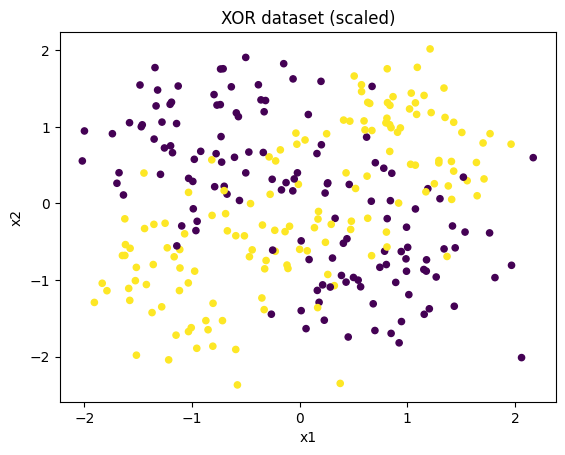

In [3]:
plt.figure()
plt.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, s=20)
plt.title("XOR dataset (scaled)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 4. SVM Classical Lineal

In [4]:
svc_linear = SVC(kernel="linear", C=1.0)
svc_linear.fit(X_train_s, y_train)

y_pred_linear = svc_linear.predict(X_test_s)

acc_linear = accuracy_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)

print("Linear SVM")
print("Accuracy:", acc_linear)
print("F1:", f1_linear)


Linear SVM
Accuracy: 0.575
F1: 0.6330935251798561


## 5. SVM CLASSICAL WITH RBF KERNEL

In [5]:
svc_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svc_rbf.fit(X_train_s, y_train)

y_pred_rbf = svc_rbf.predict(X_test_s)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)

print("RBF SVM")
print("Accuracy:", acc_rbf)
print("F1:", f1_rbf)


RBF SVM
Accuracy: 0.825
F1: 0.8421052631578947


## 6. Quantum SVM

### 6.1 Quantum feature map ZZ

In [ ]:
def encode_angles(x):
    return np.tanh(x) * (np.pi / 2)


def feature_map_circuit(x, n_qubits=2, reps=2):
    x1, x2 = encode_angles(x)
    qc = QuantumCircuit(n_qubits)

    for _ in range(reps):
        
        for q in range(n_qubits):
            qc.h(q)

        
        for q in range(n_qubits):
            angle = x1 if (q % 2 == 0) else x2
            qc.rz(2 * angle, q)

        
        for q in range(0, n_qubits, 2):
            qc.cx(q, q + 1)
            qc.rz(2 * (x1 * x2), q + 1)
            qc.cx(q, q + 1)

    return qc

### 6.2 Quantum StateVectors

In [7]:
def compute_statevectors(X, n_qubits=2, reps=2):
    states = []
    for x in X:
        qc = feature_map_circuit(x, n_qubits=n_qubits, reps=reps)
        states.append(Statevector.from_instruction(qc))
    return states

### 6.3 Quantum Kernel

In [8]:
def build_kernel_matrix_from_states(S1, S2):
    n1, n2 = len(S1), len(S2)
    K = np.zeros((n1, n2))

    for i in range(n1):
        v1 = np.conjugate(S1[i].data)
        for j in range(n2):
            overlap = v1 @ S2[j].data
            K[i, j] = np.abs(overlap) ** 2

    return K

### 6.4-5 Construction of the Kernel Matrices & Quantum SVM training with tunning

In [9]:
def run_quantum_svm(n_qubits, reps=2):
    print(f"\n=== Quantum Kernel SVM ({n_qubits} qubits) ===")

    S_train = compute_statevectors(X_train_s, n_qubits=n_qubits, reps=reps)
    S_test  = compute_statevectors(X_test_s,  n_qubits=n_qubits, reps=reps)

    K_train = build_kernel_matrix_from_states(S_train, S_train)
    K_test  = build_kernel_matrix_from_states(S_test,  S_train)

    best_acc = -1
    best_f1 = -1
    best_model = None
    best_pred = None

    for C in [0.1, 1, 10, 100]:
        svc_q = SVC(kernel="precomputed", C=C)
        svc_q.fit(K_train, y_train)
        y_pred_q = svc_q.predict(K_test)

        acc_q = accuracy_score(y_test, y_pred_q)
        f1_q  = f1_score(y_test, y_pred_q)

        print(f"[{n_qubits}q] C={C:>5} | Accuracy={acc_q:.3f} | F1={f1_q:.3f}")

        if acc_q > best_acc:
            best_acc = acc_q
            best_f1 = f1_q
            best_model = svc_q
            best_pred = y_pred_q

    return best_acc, best_f1, best_model, best_pred, S_train


reps = 2

acc_q2, f1_q2, model_q2, pred_q2, S_train_2 = run_quantum_svm(2, reps=reps)
acc_q4, f1_q4, model_q4, pred_q4, S_train_4 = run_quantum_svm(4, reps=reps)
acc_q8, f1_q8, model_q8, pred_q8, S_train_8 = run_quantum_svm(8, reps=reps)


=== Quantum Kernel SVM (2 qubits) ===
[2q] C=  0.1 | Accuracy=0.583 | F1=0.667
[2q] C=    1 | Accuracy=0.617 | F1=0.667
[2q] C=   10 | Accuracy=0.675 | F1=0.711
[2q] C=  100 | Accuracy=0.692 | F1=0.726

=== Quantum Kernel SVM (4 qubits) ===
[4q] C=  0.1 | Accuracy=0.633 | F1=0.690
[4q] C=    1 | Accuracy=0.708 | F1=0.737
[4q] C=   10 | Accuracy=0.717 | F1=0.726
[4q] C=  100 | Accuracy=0.742 | F1=0.744

=== Quantum Kernel SVM (8 qubits) ===
[8q] C=  0.1 | Accuracy=0.658 | F1=0.713
[8q] C=    1 | Accuracy=0.750 | F1=0.758
[8q] C=   10 | Accuracy=0.683 | F1=0.683
[8q] C=  100 | Accuracy=0.633 | F1=0.645


### 7. Final Comparation

### 7.1 Bar charts

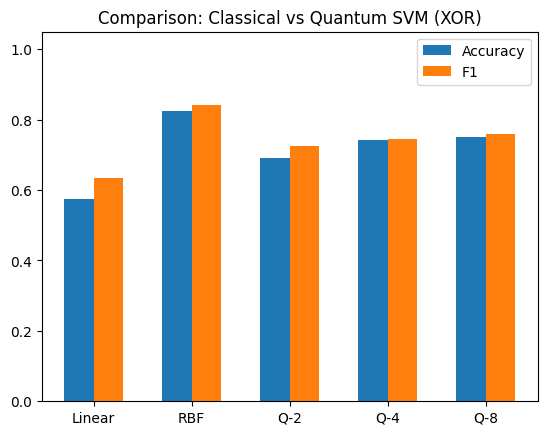

In [10]:
models = ["Linear", "RBF", "Q-2", "Q-4", "Q-8"]
accs = [acc_linear, acc_rbf, acc_q2, acc_q4, acc_q8]
f1s  = [f1_linear,  f1_rbf,  f1_q2,  f1_q4,  f1_q8]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.15, accs, width=0.3, label="Accuracy")
plt.bar(x + 0.15, f1s, width=0.3, label="F1")
plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.legend()
plt.title("Comparison: Classical vs Quantum SVM (XOR)")
plt.show()


### 7.2 Confusion Matrixes

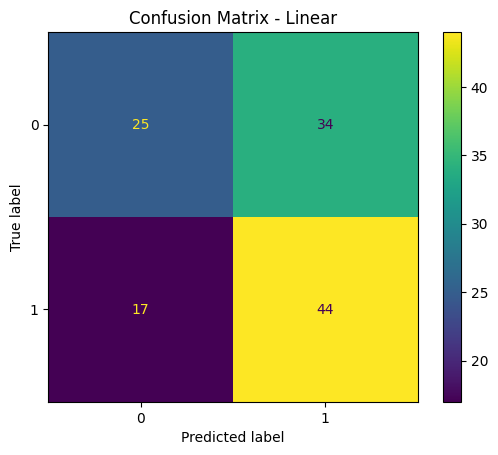

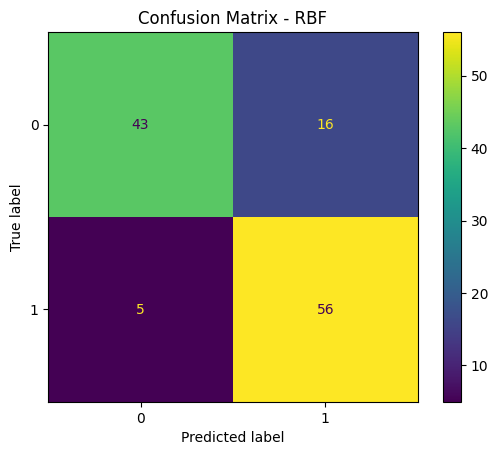

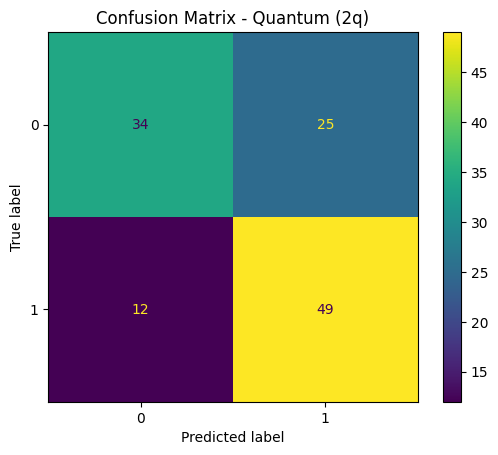

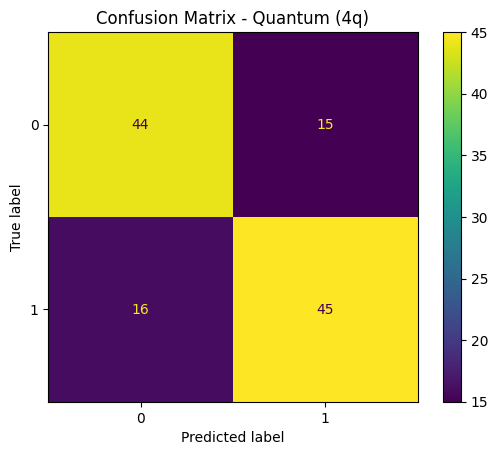

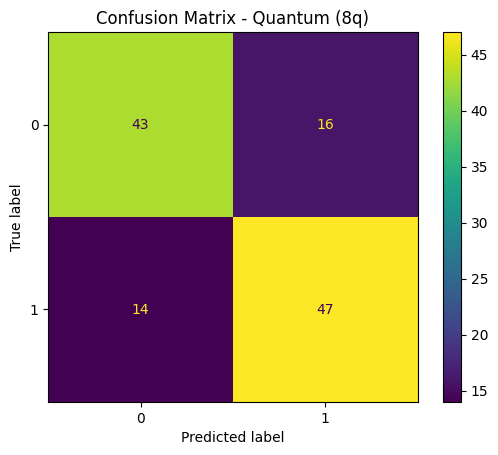

In [11]:


for name, y_pred in zip(
    ["Linear", "RBF", "Quantum (2q)", "Quantum (4q)", "Quantum (8q)"],
    [y_pred_linear, y_pred_rbf, pred_q2, pred_q4, pred_q8]
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


### 7.3 Decision Boundaries

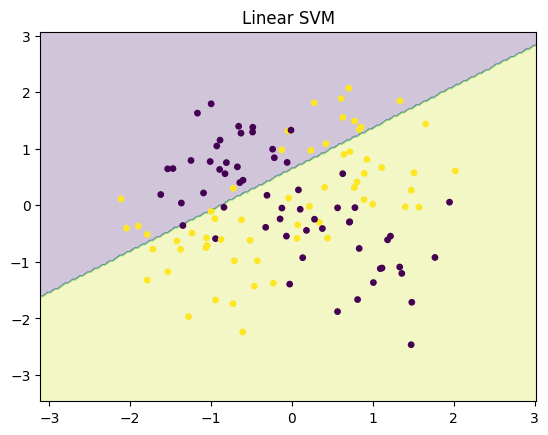

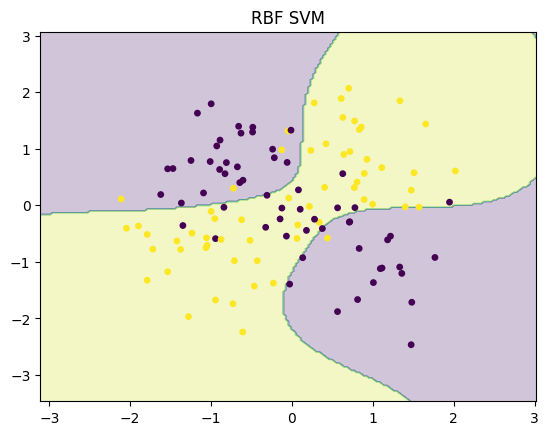

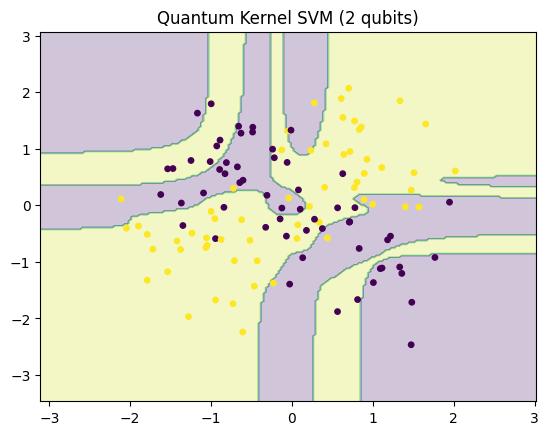

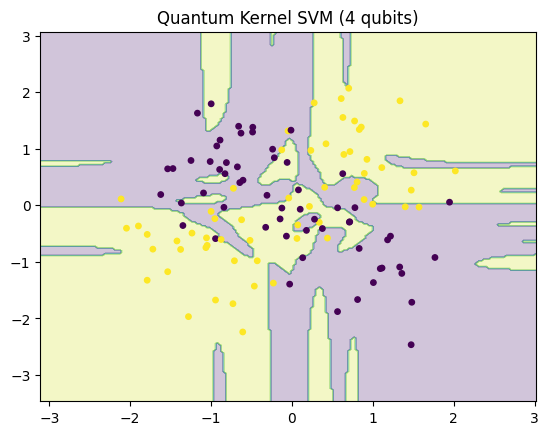

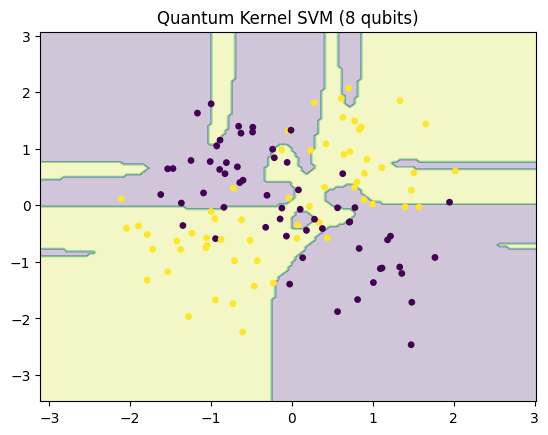

In [ ]:
def plot_decision_boundary_classical(model, X, y, title, grid_res=200):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                         np.linspace(y_min, y_max, grid_res))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=15)
    plt.title(title)
    plt.show()


def plot_decision_boundary_quantum(model, X, y, title,
                                  n_qubits, reps, S_train_ref,
                                  grid_res=200):
    """
    Correct quantum decision boundary:
    - Compute S_grid using SAME n_qubits & reps as the model
    - Build K_grid against S_train_ref (train states for that SAME n_qubits)
    - Predict on precomputed kernel
    """
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                         np.linspace(y_min, y_max, grid_res))
    grid = np.c_[xx.ravel(), yy.ravel()]

    
    S_grid = compute_statevectors(grid, n_qubits=n_qubits, reps=reps)
    K_grid = build_kernel_matrix_from_states(S_grid, S_train_ref)
    Z = model.predict(K_grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=15)
    plt.title(title)
    plt.show()
    

plot_decision_boundary_classical(svc_linear, X_test_s, y_test, "Linear SVM", grid_res=200)
plot_decision_boundary_classical(svc_rbf,    X_test_s, y_test, "RBF SVM",    grid_res=200)

plot_decision_boundary_quantum(model_q2, X_test_s, y_test,
                               "Quantum Kernel SVM (2 qubits)",
                               n_qubits=2, reps=reps, S_train_ref=S_train_2,
                               grid_res=200)

plot_decision_boundary_quantum(model_q4, X_test_s, y_test,
                               "Quantum Kernel SVM (4 qubits)",
                               n_qubits=4, reps=reps, S_train_ref=S_train_4,
                               grid_res=200)

plot_decision_boundary_quantum(model_q8, X_test_s, y_test,
                               "Quantum Kernel SVM (8 qubits)",
                               n_qubits=8, reps=reps, S_train_ref=S_train_8,
                               grid_res=150)



